# 1. The reconciliation, skipped

**Week 1, Friday. The lab debrief, chapter 1 of 3: do the quarters in your note match the books?**

Anand Iyer, finance controller, said it on Wednesday and it still holds: "Until your numbers match
ours, Finance will not act on a drop measured from an ERP export."

**The metric at stake.** Booked revenue per quarter, the rupees of the orders recorded as sales in
it, and the change from Q1 to Q2 that the note to Meera Raghavan leads with. **Who asks.** Anand,
before he lets any number reach Meera's growth review, and Meera, who acts on the first line of the
note. **What a wrong number costs.** A first line that points the wrong way sends Monday's review
after the wrong question, and Marketing's Rs 12 crore acquisition request gets judged against a
quarter that did not happen. Anand returns the note, and the team's next number is read with
suspicion.

**Who else faces this.** Nykaa, the beauty and fashion retailer, reports two numbers for the same
quarter: gross merchandise value (GMV), the value of everything customers ordered at the prices
charged, before cancellations, returns and tax come out, and revenue from operations, the income the
company books in its own accounts. For April to June 2025 they were Rs 4,182 crore and Rs 2,155
crore (FSN E-Commerce Ventures press release, 12 August 2025). An analyst there who quotes one to
the owner of the other is out by nearly half, so every internal figure says which it is and bridges
to the books. A public case shows what an unreconciled pipeline hides: in October 2020 Public Health
England said 15,841 positive COVID-19 cases from 25 September to 2 October had been left out of the
reported daily figures because files exceeded a size limit (UK government statement, 4 October
2020). No step raised an error; the rows were simply not there.

**Where this starts.** This morning each of you ran the week's method alone on the lab export. This
notebook replays the step most rooms dropped when the clock ran, the reconciliation, and shows what
the note said without it. Chapter 2 picks up the case where a count check passes and the rupees do
not; chapter 3 takes the clean numbers into the tree.

**Before you read on.** This notebook runs on this morning's lab export. A cell that would show
what sits in the file ships empty, with the lines to type in the markdown above it, so the file
keeps its findings for whoever meets it cold; type them and run them. Where a mechanism needs
numbers before yours, it is drawn on the debrief deck's invented export and labelled invented.
The notebook opens after the lab clock stops, and it is the debrief's text for self-study too.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import random
import statistics
from math import comb

rows = kit.load_csv("C2_W01_D05_lab_orders_STUDENT.csv")
control = {c["quarter"]: c for c in kit.load_csv("C2_W01_D05_lab_control_STUDENT.csv")}
QUARTERS = ("Q1", "Q2")


def change(a, b):
    """Percentage change from a to b."""
    return 100 * (b / a - 1)


def ctl(q):
    return int(control[q]["amount_rs"]), int(control[q]["orders"])


def read_value(text):
    """The number a person reads without a guess from a value typed with grouping commas, spaces,
    a Rs prefix or paise; None when reading it would need a guess."""
    t = str(text).strip().replace("Rs", "").replace(",", "").replace(" ", "")
    try:
        return round(float(t))
    except ValueError:
        return None


print(f"{len(rows)} rows read from the lab export; Finance's control totals for {', '.join(sorted(control))}")

207 rows read from the lab export; Finance's control totals for Q1, Q2


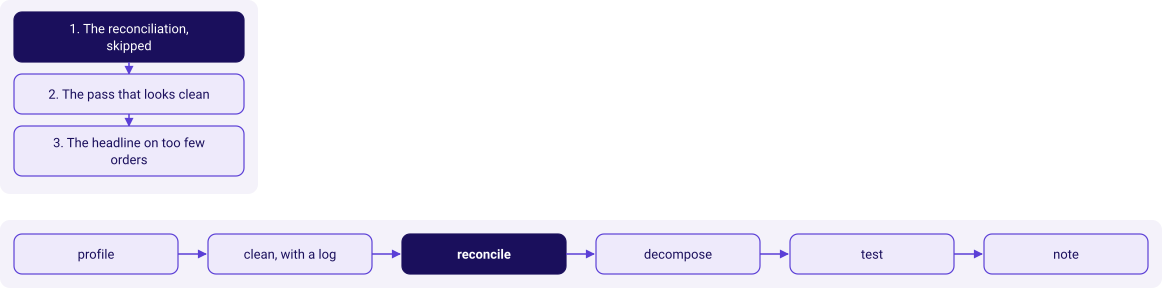

In [2]:
kit.side_by_side(
    kit.ladder(["The reconciliation, skipped", "The pass that looks clean", "The headline on too few orders"],
               lit=0, show=False),
    kit.flow(["profile", "clean, with a log", "reconcile", "decompose", "test", "note"], lit=2, show=False),
)

**The passes, as two small functions.** `quarter_totals` sums each quarter, either reading every
value with `read_value` from the first cell, which reads the forms a person reads without a guess,
or setting any value that will not convert to zero, the way the hurried pass did; `first_of_each`
keeps one row per order id, Wednesday's identity rule.

In [3]:
def quarter_totals(src, text_to_zero):
    out = {}
    for q in QUARTERS:
        s = n = 0
        for r in src:
            if r["quarter"] != q:
                continue
            v = r["amount"]
            s += (int(v) if v.isdigit() else 0) if text_to_zero else read_value(v)
            n += 1
        out[q] = (s, n)
    return out


def first_of_each(src):
    kept = {}
    for r in src:
        kept.setdefault(r["order_id"], r)
    return list(kept.values())


truth = change(ctl("Q1")[0], ctl("Q2")[0])
print(f"Finance's books: Q1 to Q2 {truth:+.1f}%")

Finance's books: Q1 to Q2 -28.5%


## 1. The headline the hurried run sent

Most notes this morning were built on a pass that kept the rows as they arrived and set any value
that would not convert to zero. It runs without an error.

**Predict before you run.** What Q1 to Q2 change does that pass report?

- a) A fall of a little under a third, the same as Finance's books.
- b) A rise of about a tenth.
- c) A fall of about a seventh.
- d) No change, since both quarters hold about a hundred orders.

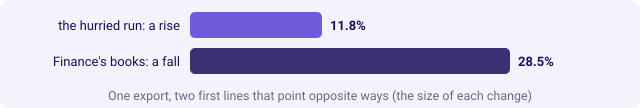

In [4]:
hurried = quarter_totals(rows, text_to_zero=True)
h_change = change(hurried["Q1"][0], hurried["Q2"][0])
kit.stats([(f"{h_change:+.1f}%", "Q1 to Q2, the hurried run", "the line the note led with"),
           (f"{truth:+.1f}%", "Q1 to Q2, Finance's books", "from the control file"),
           ("0", "errors raised", "the pass ran to the end")])
kit.bars([("the hurried run: a rise", round(abs(h_change), 1)), ("Finance's books: a fall", round(abs(truth), 1))],
         fmt=lambda v: f"{v:.1f}%", lit=(1,), width=640,
         title="One export, two first lines that point opposite ways (the size of each change)")

**What happened.** The answer is b. The pass reports Q2 up 11.8 percent, and Finance's own control
file says the quarter fell 28.5 percent.

**The plausible wrong answer.** "Q2 grew 11.8 percent; no action needed on the top line." The
arithmetic is right, the file is Finance's own export, and nothing on the screen looks broken.

**Why it is wrong.** Nobody asked whether the data summed is the data Finance booked. Sent to Meera,
the line tells her the quarter that fell was a good one, and the review spends its time on
Marketing's plans instead of on the fall. The check is one comparison with the control file.

**Your turn.** Put the hurried run beside Finance's control totals, quarter by quarter, in orders
and in rupees. Type these lines into the empty cell below and run it:

```python
kit.table(["quarter", "rows summed", "Finance's orders", "rupees summed", "Finance's rupees"],
          [(q, hurried[q][1], ctl(q)[1], kit.rupees(hurried[q][0]), kit.rupees(ctl(q)[0]))
           for q in QUARTERS], caption="The hurried run against the control totals")
```

Which misses does each quarter show: in orders, in rupees, or both?

In [5]:
kit.check("the hurried run misses Finance's rupee totals", any(hurried[q][0] != ctl(q)[0] for q in QUARTERS))
kit.check("the hurried run points the opposite way to the books", h_change > 0 > truth,
          f"{h_change:+.1f}% against {truth:+.1f}%")

## The options

The question at this step is narrow: before a single branch of the tree is read, is the data you
cleaned still the data Finance booked? A team has four ways to answer it.

| Option | What it does | What it needs |
|---|---|---|
| A. Trust the pass | Sum what the cleaning pass kept and move on to the tree | Nothing |
| B. Count check | Rows read equal rows kept plus rows rejected, and orders per quarter equal Finance's order counts | The control file's order counts |
| C. Counts and rupees, with a bridge | B, plus each quarter's rupees against Finance's control total, and a bridge from what was read to what was kept | The control file's rupee totals |
| D. Order-level match | Every kept order matched to Finance's ledger line by line | The ledger itself, which the lab did not have |

The cell below sizes the options on what separates them: the minutes and cells each costs, what it
needs from outside the file, the kind of error it can see, and how far the headline it lets through
sits from the books. It runs the hurried pass and then applies each check, fixing only what that
check can see. D cannot run here, since the lab had no ledger, so its row says what it would need
and find and claims no headline. The minutes are the lab brief's pace, and D's is this programme's
estimate for a request to Finance and a join.

option,analyst minutes,cells,what it needs,what it can see,Q1 to Q2 it lets through,points off the books
A. trust the pass,0,0,nothing,nothing,+11.8%,40.3
B. count check,2,1,Finance's order counts,rows beyond Finance's orders,-14.6%,13.9
"C. counts and rupees, bridge",15,3,Finance's rupee totals too,"extra rows, and rupees the kept rows lost",-28.5%,0.0
D. order-level match,about 120,6,Finance's ledger,"every order that differs, by id",not run: no ledger,not run


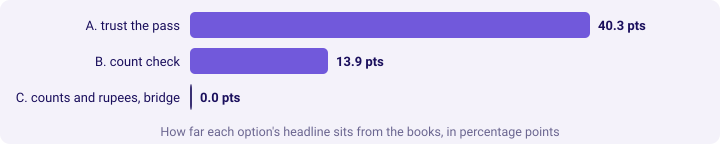

In [6]:
sizing = []
for name, minutes, cells, needs, sees, dedupe, text_fixed in [
        ("A. trust the pass", 0, 0, "nothing", "nothing", False, False),
        ("B. count check", 2, 1, "Finance's order counts", "rows beyond Finance's orders", True, False),
        ("C. counts and rupees, bridge", 15, 3, "Finance's rupee totals too",
         "extra rows, and rupees the kept rows lost", True, True)]:
    t = quarter_totals(first_of_each(rows) if dedupe else rows, text_to_zero=not text_fixed)
    reported = change(t["Q1"][0], t["Q2"][0])
    sizing.append((name, minutes, cells, needs, sees, f"{reported:+.1f}%", round(abs(reported - truth), 1)))
sizing.append(("D. order-level match", "about 120", 6, "Finance's ledger", "every order that differs, by id",
               "not run: no ledger", "not run"))
kit.table(["option", "analyst minutes", "cells", "what it needs", "what it can see", "Q1 to Q2 it lets through",
           "points off the books"], sizing,
          caption=f"Four ways to check, sized on the lab export; the books say {truth:+.1f}%")
kit.bars([(s[0], s[6]) for s in sizing[:3]], lit=(2,), fmt=lambda v: f"{v:.1f} pts",
         title="How far each option's headline sits from the books, in percentage points")

In [7]:
kit.check("only C, of the options that can run here, lands on the books",
          sizing[2][6] == 0 and all(s[6] > 1 for s in sizing[:2]))
kit.check("the count check moves the headline and still misses the books",
          sizing[1][5] != sizing[0][5] and sizing[1][6] > 1)

**The best-fit call.** C. It costs about fifteen minutes of an analyst's two hours, needs only the
control file that came with the export, and is the only option run here that lands on the books to
the rupee. B is the option most people who did check stopped at, and it still leaves the headline
about 14 points off. D would name every order that differs, which C cannot, and it costs a request
to Finance and most of the afternoon.

**What would change the call.** No control total at all: then C has nothing to land on, and D, or a
second export pulled from the source system for the same quarters, becomes the check. A bridge that
does not close: then C has told you there is a gap it cannot explain, and D is how you find it.

## 2. The count check

Option B compares orders with Finance's order counts and keeps one row per order id, the identity
rule from Wednesday.

**Predict before you run.** After B's fix, what does the headline say?

- a) Q2 up 11.8 percent, unchanged.
- b) Q2 down 28.5 percent, the books.
- c) Q2 down 14.6 percent.
- d) The check cannot run without the order-level ledger.

In [8]:
once = first_of_each(rows)
counted = quarter_totals(once, text_to_zero=True)
c_change = change(counted["Q1"][0], counted["Q2"][0])
seen, rejected = set(), []
for r in rows:
    if r["order_id"] in seen:
        rejected.append(r)
    seen.add(r["order_id"])
kit.check("input equals kept plus rejected, each list built on its own", len(rows) == len(once) + len(rejected))
kit.check("the order counts now land on Finance's in both quarters",
          all(counted[q][1] == ctl(q)[1] for q in QUARTERS))
kit.check("the rupees still miss Finance's control totals", any(counted[q][0] != ctl(q)[0] for q in QUARTERS))
print(f"Q1 to Q2 after the count check: {c_change:+.1f}%; the books say {truth:+.1f}%")

Q1 to Q2 after the count check: -14.6%; the books say -28.5%


**What happened.** The answer is c. Every order count lands, and the headline moves from +11.8 to
-14.6 percent: the right direction and half the size. A count check proves the rows are there; it
says nothing about whether each row's value survived the conversion. That is chapter 2's trap, and it
is the one a pass that "looks clean" leaves behind.

**Your turn.** See what the count check kept and set aside. Type these lines into the empty cell
below and run it:

```python
kit.table(["quarter", "orders kept", "Finance's orders", "rupees kept", "Finance's rupees"],
          [(q, counted[q][1], ctl(q)[1], kit.rupees(counted[q][0]), kit.rupees(ctl(q)[0]))
           for q in QUARTERS],
          caption=f"After the count check: {len(rows)} rows read, {len(once)} kept, {len(rejected)} set aside")
```

## 3. Counts and rupees, and the bridge between them

Option C adds the rupee comparison and draws the walk from what the hurried run summed to what
Finance booked, one move per decision in the log. The first bridge below is drawn on invented
numbers, the invented export on the debrief's slides, so the shape is visible before you draw your
own: an export as a hurried pass summed it, the rows Finance does not hold taken out, the value that
would not convert read back in, and the walk landing on Finance's two quarters. None of its numbers
is Kalpa's or this morning's.

**Predict before you run.** On the invented export, which move is the larger?

- a) The rows the control total does not contain.
- b) The value that would not convert.
- c) They are equal.
- d) Neither; the bridge closes with no moves.

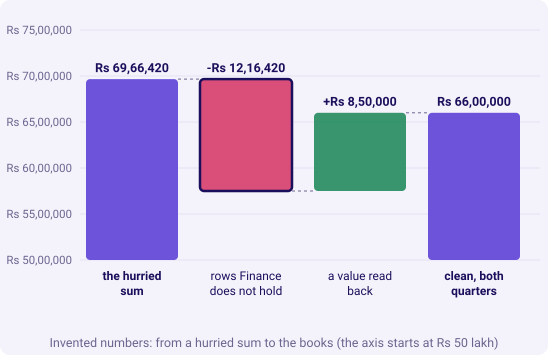

In [9]:
# Invented numbers: the debrief deck's invented export, labelled invented wherever they appear.
kit.bridge(("the hurried sum", 6_966_420), [("rows Finance does not hold", -1_216_420),
                                            ("a value read back", 850_000)],
           end_label="clean, both quarters", lit=[0], lo=5_000_000,
           title="Invented numbers: from a hurried sum to the books (the axis starts at Rs 50 lakh)")

In [10]:
clean = quarter_totals(once, text_to_zero=False)
as_read = sum(hurried[q][0] for q in QUARTERS)
extra_rows = sum(counted[q][0] for q in QUARTERS) - as_read
text_back = sum(clean[q][0] for q in QUARTERS) - sum(counted[q][0] for q in QUARTERS)
kit.check("this morning's bridge lands on Finance's two quarters together",
          as_read + extra_rows + text_back == ctl("Q1")[0] + ctl("Q2")[0], kit.rupees(ctl("Q1")[0] + ctl("Q2")[0]))
kit.check("both quarters land, orders and rupees", all(clean[q] == ctl(q) for q in QUARTERS))

**What happened.** The answer is a, on the invented export: the rows Finance does not hold carry
Rs 12,16,420 against the Rs 8,50,000 read back, and both moves had to be found before the walk
landed. The checks above say this morning's bridge lands too.

**Your turn.** Draw this morning's bridge and read which move is the larger on this file. Type these
lines into the empty cell below and run it:

```python
kit.bridge(("the hurried sum", as_read), [("rows Finance does not hold", extra_rows),
                                          ("a value read back", text_back)],
           end_label="clean, both quarters", lit=[0], lo=9_000_000,
           title="From the hurried sum to the books (the axis starts at Rs 90 lakh)")
```

**The fix, and what it changes.** With both quarters on the books, the headline is a fall of 28.5
percent, from Rs 60,48,000 to Rs 43,25,480. The note changes sign, so the decision changes with it:
Monday's review now has a fall of Rs 17,22,520 to explain, and chapter 3 finds where it sits.

run,Q1 to Q2
the hurried run,+11.8%
count check only,-14.6%
counts and rupees,-28.5%


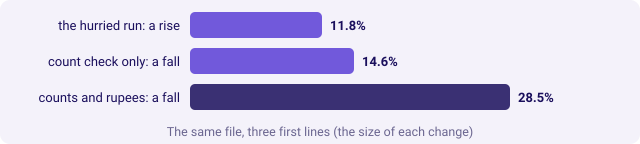

In [11]:
variants = [("the hurried run", hurried), ("count check only", counted), ("counts and rupees", clean)]
heads = [(n, change(t["Q1"][0], t["Q2"][0])) for n, t in variants]
kit.table(["run", "Q1 to Q2"], [(n, f"{h:+.1f}%") for n, h in heads], caption="One export, three headlines")
kit.bars([(f"{n}: {'a rise' if h > 0 else 'a fall'}", round(abs(h), 1)) for n, h in heads], lit=(2,),
         fmt=lambda v: f"{v:.1f}%", width=640, title="The same file, three first lines (the size of each change)")

**Your turn.** The bridge says how many rupees Finance does not hold. It does not say which rows
they are, and Anand will ask. Type these lines into the empty cell below and run it:

```python
seen, extra = set(), []
for r in rows:
    if r["order_id"] in seen:
        extra.append(r)
    seen.add(r["order_id"])
kit.table(list(rows[0]), [list(r.values()) for r in extra], caption="Rows Finance does not hold")
```

Read the dates and the segments: what do the rows have in common, and what would you tell the
person who owns the export?

## A second route: sum the decisions themselves

The bridge's two moves were found by subtracting one total from another. The second route builds the
evidence on its own and sums it: every row set aside as a repeat of an order already kept, summed
from the set-aside list, and every value read back from text, summed from the decisions log. Each
must equal its move in the bridge. The first route is arithmetic on totals, and this one is a sum of
the decisions themselves, so a row set aside without its log line, or a value zeroed where it should
have been read, makes the two disagree.

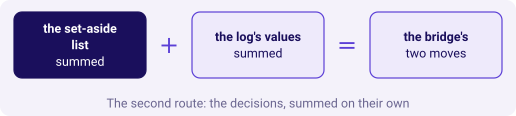

In [12]:
set_aside, log, kept_ids = [], [], set()
for r in rows:
    if r["order_id"] in kept_ids:
        set_aside.append(r)
        continue
    kept_ids.add(r["order_id"])
    if not r["amount"].isdigit():
        log.append({"order_id": r["order_id"], "decision": "convert and flag", "read_as": read_value(r["amount"])})
set_aside_rupees = sum(read_value(r["amount"]) for r in set_aside)
read_back = sum(e["read_as"] for e in log)
kit.equation(["the set-aside list\nsummed", "+", "the log's values\nsummed", "=", "the bridge's\ntwo moves"],
             title="The second route: the decisions, summed on their own")
kit.check("the rows set aside add up to the rupees the bridge took out", set_aside_rupees == -extra_rows)
kit.check("the values in the log add up to the rupees the bridge read back", read_back == text_back)

**When to switch routes.** Show Finance the forward bridge, because it starts from their export.
Run this second route before you send it: it proves every rupee the bridge moved is a row in the
set-aside list or a value in the log, each summed on its own. It cannot tell you whether each
decision was right, whether a row set aside really repeats an order or a value was read correctly;
the order-level match is what answers that.

### Depth: the same rows can move a branch

Rows Finance does not hold inflate a total, and when they sit in one segment they can move a branch
as well: extra rows for the same customers read as customers ordering more often. **Your turn.** Run
the tree on the hurried rows and on the one-row-per-order list for each consumer segment, and compare
the orders-per-customer branch:

```python
def branch(src, q, seg):
    rs = [r for r in src if r["quarter"] == q and r["segment"] == seg and r["amount"].isdigit()]
    return len(rs) / len({r["customer_id"] for r in rs}), sum(int(r["amount"]) for r in rs) / len(rs)

for seg in ("Retail-Core", "Retail-Plus", "Student"):
    (fh1, _), (fh2, _) = branch(rows, "Q1", seg), branch(rows, "Q2", seg)
    (fc1, bc1), (fc2, bc2) = branch(once, "Q1", seg), branch(once, "Q2", seg)
    print(f"{seg}: orders per customer {fh1:.2f} to {fh2:.2f} on the hurried rows, "
          f"{fc1:.2f} to {fc2:.2f} one row per order; revenue per order {change(bc1, bc2):+.1f}%")
```

Where do the rows Finance does not hold sit, and which branch would a note built on the hurried rows
have named?

> **Kavya's review.** A number that has not been reconciled can point the wrong way, and this
> morning it did. Put the two checks in a cell before you compute the first number you plan to
> send, so the clock cannot remove them.

### In the interview

**[S] Walk me through how you clean and check a dataset you have never seen.** "I profile every
field first: present, convertible and distinct counts, and each count that is not what the field
should hold is a finding. I clean with a log, one row per decision with its reason, and I keep what
I reject. Then I reconcile before I analyse: rows read equal rows kept plus rows rejected, and each
period's value lands on a total from outside the file, Finance's if there is one. On a lab export
last week the count check alone moved my headline from +11.8 to -14.6 percent, and only the rupee
check got it to the books' -28.5, so I never stop at counts."

**[F] You have two hours and a raw export; what do you do first, and what do you skip?** "Profile
first, twenty minutes. I never skip the reconciliation, because it is the step that can flip the
sign of the finding and it costs fifteen minutes. I skip anything that does not change today's
answer: a second chart, a test on every segment, polishing. If there is no control total I say so
in the caveat and ask for one before the number leaves the room."

**The design question: which check, and what would make you switch?** "Counts and rupees against a
control total with a bridge, because it catches both kinds of error for fifteen minutes and needs
only what comes with the export. I switch to an order-level match against the ledger when the bridge
will not close or when there is no control total, and I say it will cost the afternoon."

**Depth: when there is no control total.** Three stand-ins, in the order a careful analyst tries
them: the same quarters in a second export pulled from the source system on another day; the
payment gateway's settlement totals for the quarter, which count collected rather than booked
money and so need their own bridge; last quarter's audited figure for the quarter that overlaps.
Each is weaker than Finance's number, and the note says which one was used.

In [13]:
kit.check_summary()